# Defaut residuel de propagateToDAG : v-structure inventee sur un CPDAG cordal valide (agrum2 ET agrum3)

P est un CPDAG valide entierement non oriente (6 noeuds, squelette cordal — verifie en cellule 2) :
sa classe de Markov est l'ensemble des orientations acycliques sans collider non blinde,
non vide car le squelette est cordal. Une completion correcte ne doit donc creer **aucune** v-structure.

Resultat : les **deux** versions completent P en creant la v-structure interdite `1 -> 0 <- 5`
(1 et 5 non adjacents).

Contrairement a l'exemple de `r3_meek_example.ipynb` (ou seul agrum2 fautait — bug R3, corrige
dans agrum3), ce defaut-ci est **commun aux deux versions** : il vient de l'heuristique de choix
des orientations arbitraires de `propagateToDAG`, pas de R3. Il est rare : 1 CPDAG sur 2279 dans
une enumeration aleatoire (4 a 6 noeuds), ~2 squelettes cordaux sur 500 dans un second tirage.

Les verifications (cordalite, v-structures) sont faites en python pur, sans oracle agrum.

Run All avec un kernel agrum3 (cbnsl), puis Run All avec un kernel agrum2 (venv) ;
la derniere cellule compare.

In [1]:
import itertools
import json
from pathlib import Path

import pyagrum as gum
import pyagrum.lib.notebook as gnb

VERSION = f"agrum{gum.__version__.split('.')[0]}"
RESULTS = Path("/tmp/meek_residual_case")
RESULTS.mkdir(parents=True, exist_ok=True)
print(VERSION, "| pyagrum", gum.__version__)

agrum2 | pyagrum 2.3.0


squelette cordal : OK (aucun cycle sans corde)


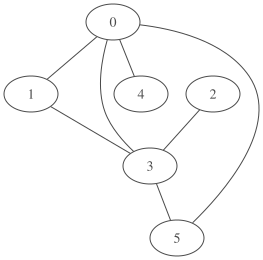

In [2]:
# P : CPDAG valide, entierement non oriente (6 noeuds).
EDGES = [(0, 1), (0, 3), (0, 4), (0, 5), (1, 3), (2, 3), (3, 5)]
N = 6
SKEL = {frozenset(e) for e in EDGES}

# cordalite verifiee par force brute : aucun cycle de longueur >= 4 sans corde
adj = {i: set() for i in range(N)}
for u, v in EDGES:
    adj[u].add(v); adj[v].add(u)

def chordless_cycle():
    for k in range(4, N + 1):
        for cyc in itertools.permutations(range(N), k):
            if cyc[0] != min(cyc) or cyc[1] > cyc[-1]:
                continue
            if all(cyc[i + 1] in adj[cyc[i]] for i in range(k - 1)) and cyc[0] in adj[cyc[-1]]:
                chords = [frozenset((cyc[i], cyc[j])) for i in range(k) for j in range(i + 2, k)
                          if not (i == 0 and j == k - 1)]
                if not any(c in SKEL for c in chords):
                    return cyc
    return None

assert chordless_cycle() is None
print("squelette cordal : OK (aucun cycle sans corde)")

P = gum.MixedGraph()
for i in range(N):
    P.addNodeWithId(i)
for u, v in EDGES:
    P.addEdge(u, v)
gnb.showDot(P.toDot())

In [3]:
dag = gum.MeekRules().propagateToDAG(P)
dag_arcs = sorted([t, h] for t, h in dag.arcs())

# v-structures creees par la completion, detectees en python pur
colliders = []
for c in dag.nodes():
    for a, b in itertools.combinations(sorted(dag.parents(c)), 2):
        if frozenset((a, b)) not in SKEL:
            colliders.append([a, c, b])

same_skel = {frozenset(a) for a in map(tuple, dag_arcs)} == SKEL
print(f"{VERSION} : squelette conserve : {same_skel}")
print(f"{VERSION} : v-structures creees : {colliders or 'aucune'}")

(RESULTS / f"{VERSION}.json").write_text(json.dumps({
    "dag_arcs": dag_arcs, "colliders": colliders}))

agrum2 : squelette conserve : True
agrum2 : v-structures creees : [[1, 0, 5]]


96

In [4]:
versions = sorted(f.stem for f in RESULTS.glob("agrum*.json"))
assert len(versions) == 2, "lancer d'abord ce notebook dans les deux kernels (cbnsl et venv)"

displays = [gnb.getDot(P.toDot())]
captions = ["golden CPDAG P (valide, cordal)"]
for v in versions:
    r = json.loads((RESULTS / f"{v}.json").read_text())
    verdict = "NEUTRE" if not r["colliders"] else f"NON NEUTRE — v-structure {r['colliders']}"
    print(f"{v} : propagateToDAG(P) = {r['dag_arcs']}  ->  {verdict}")
    d = gum.DAG()
    d.addNodes(N)
    for t, h in r["dag_arcs"]:
        d.addArc(t, h)
    displays.append(gnb.getDot(d.toDot()))
    captions.append(f"propagateToDAG(P) {v}\n{verdict}")

gnb.sideBySide(*displays, captions=captions)

agrum2 : propagateToDAG(P) = [[0, 4], [1, 0], [1, 3], [3, 0], [3, 2], [3, 5], [5, 0]]  ->  NON NEUTRE — v-structure [[1, 0, 5]]
agrum3 : propagateToDAG(P) = [[0, 4], [1, 0], [1, 3], [3, 0], [3, 2], [3, 5], [5, 0]]  ->  NON NEUTRE — v-structure [[1, 0, 5]]


"no_name <!-- 0 --> 0 0 <!-- 1 --> 1 1 <!-- 0->1 --> 0->1 <!-- 3 --> 3 3 <!-- 0->3 --> 0->3 <!-- 4 --> 4 4 <!-- 0->4 --> 0->4 <!-- 5 --> 5 5 <!-- 0->5 --> 0->5 <!-- 1->3 --> 1->3 <!-- 2 --> 2 2 <!-- 2->3 --> 2->3 <!-- 3->5 --> 3->5 golden CPDAG P (valide, cordal)","G <!-- 0 --> 0 0 <!-- 4 --> 4 4 <!-- 0->4 --> 0->4 <!-- 1 --> 1 1 <!-- 1->0 --> 1->0 <!-- 3 --> 3 3 <!-- 1->3 --> 1->3 <!-- 2 --> 2 2 <!-- 3->0 --> 3->0 <!-- 3->2 --> 3->2 <!-- 5 --> 5 5 <!-- 3->5 --> 3->5 <!-- 5->0 --> 5->0 propagateToDAG(P) agrum2 NON NEUTRE — v-structure [[1, 0, 5]]","G <!-- 0 --> 0 0 <!-- 4 --> 4 4 <!-- 0->4 --> 0->4 <!-- 1 --> 1 1 <!-- 1->0 --> 1->0 <!-- 3 --> 3 3 <!-- 1->3 --> 1->3 <!-- 2 --> 2 2 <!-- 3->0 --> 3->0 <!-- 3->2 --> 3->2 <!-- 5 --> 5 5 <!-- 3->5 --> 3->5 <!-- 5->0 --> 5->0 propagateToDAG(P) agrum3 NON NEUTRE — v-structure [[1, 0, 5]]"
